### Middleware
Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

* Tracking agent behavior with logging, analytics, and debugging.
* Transforming prompts, tool selection, and output formatting.
* Adding retries, fallbacks, and early termination logic.
* Applying rate limits, guardrails, and PII detection.


In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [13]:
from langchain.chat_models import init_chat_model

model = init_chat_model("groq:qwen/qwen3-32b")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021426009FD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002142600ACF0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

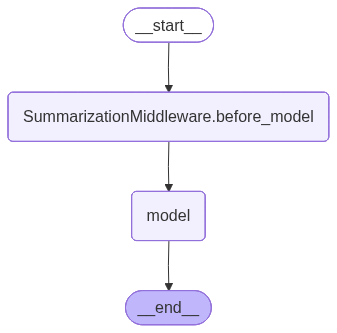

In [15]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage


### Messagebased summarization
agent=create_agent(
    model= model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)
agent

In [16]:
### Run with thread id
config={"configurable":{"thread_id":"test-1"}}

In [ ]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response['messages'][-1].content}")
    print(f"Messages: {len(response['messages'])}")


KeyError: 'results'